In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../include')

from phase_shifts import compute_phase_shifts, fit_potential, convert_to_wavenumber
from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

## Fit parameters from ³S₁ phase shifts

Use the Stoks *et al.* PRC 48 (1993) 792 data (low-energy subset, $T_\mathrm{lab} \leq 100$ MeV)
to fit the two Gaussian parameters $V_0$ and $R_0$ by minimising

$$\chi^2 = \sum_i \bigl[\delta_0(k_i; V_0, R_0) - \tilde\delta(k_i)\bigr]^2$$

Simple central potentials cannot reproduce the high-energy phase shifts (missing repulsive core),
so we restrict the fit to the low-energy region where the potential shape is most constrained.

In [4]:
# Stoks et al., PRC 48 (1993) 792, Table V  (low-energy subset, Tlab <= 100 MeV)
Tlab   = np.array([1, 5, 10, 25, 50], dtype=float)
np_3S1 = np.array([147.747, 118.178, 102.611, 80.63, 62.77])
k_exp, _ = convert_to_wavenumber(Tlab, input_type='T_lab')

# Gaussian template:  V(r) = -V0 * exp(-r^2 / R0^2)
def V_gauss(r, V0, R0):
    return -V0 * np.exp(-r**2 / R0**2)

params_opt, res = fit_potential(
    V_gauss,
    params_init=[70.0, 1.5],
    k_data=k_exp, delta_data=np_3S1,
    bounds=[(10, 300), (0.5, 4.0)],
    n_bound_states=1,
)
V0, R0 = params_opt

print(f'Fitted parameters:')
print(f'  V0 = {V0:.3f} MeV    R0 = {R0:.4f} fm')
print(f'  chi2 = {res.fun:.4g}   converged: {res.success}')
print()

delta_fit = compute_phase_shifts(lambda r: V_gauss(r, *params_opt), k_exp, n_bound_states=1)
print(f'{"Tlab":>6}  {"data":>8}  {"fit":>8}  {"resid":>7}')
for Tl, de, df in zip(Tlab, np_3S1, delta_fit):
    print(f'{Tl:6.0f}  {de:8.3f}  {df:8.3f}  {df-de:+7.3f}')

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Fitted parameters:
  V0 = 61.784 MeV    R0 = 1.6421 fm
  chi2 = 0.8924   converged: True

  Tlab      data       fit    resid
     1   147.747   148.087   +0.340
     5   118.178   118.249   +0.071
    10   102.611   102.311   -0.300
    25    80.630    80.074   -0.556
    50    62.770    63.381   +0.611


Solve with scipy

Ground state energy E = -2.374371 MeV


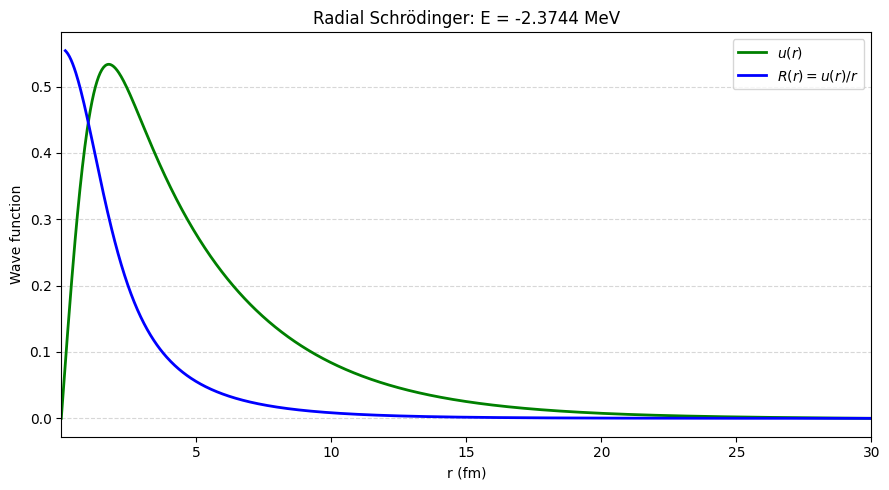

In [5]:
def V(r):
    return -V0 * np.exp(-r**2 / R0**2)

E_scipy, u_scipy, R_scipy = solve_1channel(V, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [6]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = None

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return -V0 * torch.exp(-r**2 / R0**2)

Train with Rayleigh energy only

In [7]:
cfg = TrainConfig()
cfg.n_rayleigh = 5000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 9.76366901397705, 'rayleigh': -0.10487391799688339, 'norm_loss': 0.9868537187576294, 'boundary_loss': 5.354637551135966e-07, 'E': -0.10487391799688339}
{'step': 500, 'loss': -3.2322423458099365, 'rayleigh': -3.2877087593078613, 'norm_loss': 0.005546586122363806, 'boundary_loss': 5.824574955681783e-08, 'E': -3.2877087593078613}
{'step': 1000, 'loss': -2.0942041873931885, 'rayleigh': -2.105041980743408, 'norm_loss': 0.0010837344452738762, 'boundary_loss': 5.931639179834747e-08, 'E': -2.105041980743408}
{'step': 1500, 'loss': -2.307805061340332, 'rayleigh': -2.3080925941467285, 'norm_loss': 2.7455967938294634e-05, 'boundary_loss': 1.2791359722541529e-06, 'E': -2.3080925941467285}
{'step': 2000, 'loss': -2.803439140319824, 'rayleigh': -2.823253870010376, 'norm_loss': 0.001981347566470504, 'boundary_loss': 1.2080752753718116e-07, 'E': -2.823253870010376}
{'step': 2500, 'loss': -1.4959659576416016, 'rayleigh': -1.5460842847824097, 'norm_loss': 0.0050117545761168, 'boundar

In [8]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -2.3587928
  norm_loss: 0.010610667
  pde_loss: 0.34588483
  u_rmax: -0.00054693705
  l2: 0.012780111
  learned_energy: -2.3990507
  energy_error: 0.024679403


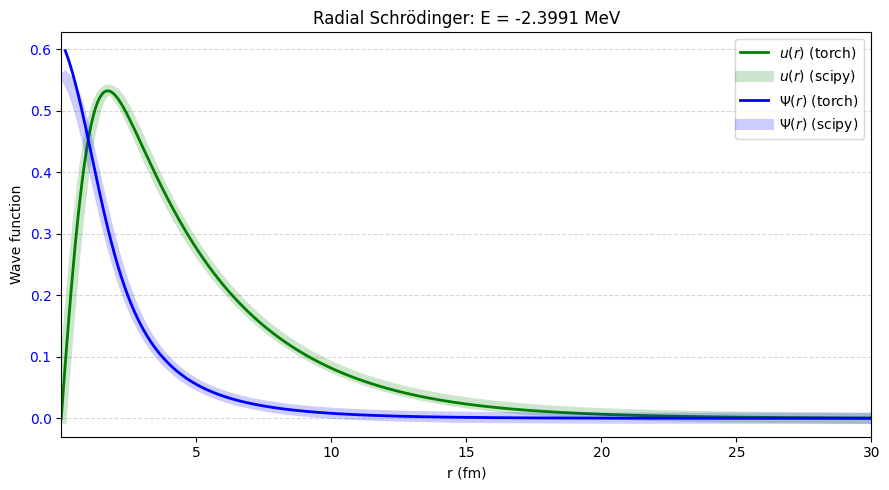

In [9]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [10]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
#cfg2.n_pde = 8000
#cfg2.n_rayleigh = 8000
#cfg2.grad_balance_pde_scale = 3.0
#cfg2.grad_balance_match_scale = 2.0

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-3)

{'step': 1, 'loss': 14.123026847839355, 'rayleigh': 4.124350547790527, 'pde_loss': 0.006245894357562065, 'match_loss': 50.756370544433594, 'norm_loss': 0.9998674392700195, 'boundary_loss': 1.9987098198726017e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -2.1333320140838623, 'rayleigh': -2.171914577484131, 'pde_loss': 54.48830032348633, 'match_loss': 0.6857254505157471, 'norm_loss': 0.003857164178043604, 'boundary_loss': 1.0868305935218814e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -1.3659590482711792, 'rayleigh': -1.3696752786636353, 'pde_loss': 20.160743713378906, 'match_loss': 2.657958745956421, 'norm_loss': 0.0003698276123031974, 'boundary_loss': 1.8058418618238647e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -2.3508501052856445, 'rayleigh': -2.351475238800049, 'pde_loss': 7.362071990966797, 'match_loss': 0.42058438062667847, 'norm_loss': 6.250986189115793e-05, 'boundary_loss': 1.16

In [11]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -2.3366511
  norm_loss: 0.00092482922
  pde_loss: 0.025316533
  u_rmax: 0.0013430277
  l2: 0.078640535
  learned_energy: -2.4070399
  energy_error: 0.032668571


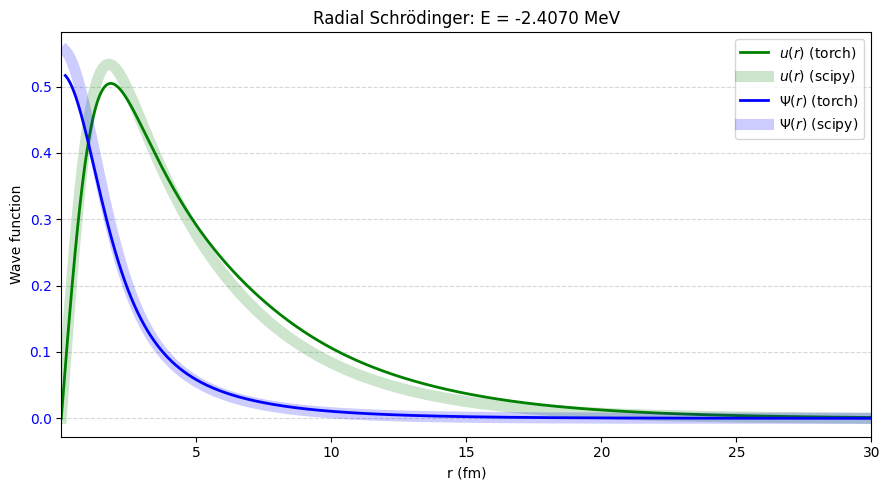

In [12]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])